In [13]:
import numpy as np

In [22]:
data=np.array([[4.427600818242255,-0.2055493353671238,4.427600818242255],
[2.9460178356229356,-0.2613303877995026,2.9460178356229356],
[3.1040674098561647,1.3052260562340352,3.1040674098561647],
[5.609476963557052,3.6679948308177455,5.609476963557052],
[3.2180217763769474,-0.6708519396932702,3.2180217763769474],
[3.5059398674481463,-0.1483511634077948,3.5059398674481463],
[4.593492764236247,-2.108242147585418,4.593492764236247],
[2.807751857521425,0.37878498037997205,2.807751857521425],
[3.0757008280100706,-0.565585410987993,3.0757008280100706],
[2.8292839628675344,0.32991475520853697,2.8292839628675344],
[3.0283242373466632,-0.39130643811406,3.0283242373466632],
[2.967291041466846,0.34571582147832947,2.967291041466846],
[3.4431738711466258,-1.0213857868476557,3.4431738711466258],
[3.907249135408928,1.5321584185607056,3.907249135408928],
[4.027526406076244,-1.8114587491710108,4.027526406076244],
[3.628641047692023,1.2604494706540021,3.628641047692023],
[2.900076792541271,0.09735897013860546,2.900076792541271],
[3.439130912171139,1.5988291747324683,3.439130912171139],
[3.3776227414316513,-0.09090386665932276,3.3776227414316513],
[4.162893666313032,-0.7046632006598422,4.162893666313032]])
x=data[:,0]
y=data[:,1]
z=data[:,2]
X=[1.2, 1.3, -2,4,0.1]
def f(X):
  z_est=X[0]+X[1]*x+X[2]*x**2+X[3]*y+X[4]*y**2
  error=np.mean((z-z_est)**2)
  return error
f(X)

np.float64(655.3729194443576)

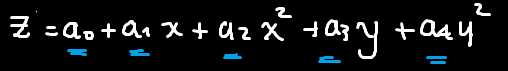

In [23]:
class agente:
  def __init__(self, funcion, W=1, C1=1, C2=1):
    self.X=np.random.uniform(low=-5, high=5, size=5)
    self.V=0.2*np.random.randn(5)
    self.funcion=funcion
    self.PBest=self.X.copy()
    self.PBestValue=funcion(self.X)
    self.Gbest=self.X.copy()
    self.W=W
    self.C1=C1
    self.C2=C2
    self.historia=[self.X]
  def cambiar(self):
    self.X=self.X+self.V
    self.V=self.W*self.V+self.C1*np.random.rand()*(self.PBest-self.X)+self.C2*np.random.rand()*(self.Gbest-self.X)
    self.historia.append(self.X)
    z=self.funcion(self.X)
    if(z<self.PBestValue):
      self.PBestValue=z
      self.PBest=self.X.copy()

def findGbest(agentes):
  vmin=1e20
  for ag in agentes:
    if(ag.PBestValue<vmin):
      vmin=ag.PBestValue
      Gbest=ag.PBest
  return Gbest


In [29]:
M=1000
from tqdm import tqdm
agentes=[agente(f, W=0.7, C1=0.1, C2=0.2) for i in range(M)]
error=[]
for i in tqdm(range(200)):
  Gbest=findGbest(agentes)
  for ag in agentes:
    ag.Gbest=Gbest.copy()
  for ag in agentes:
    ag.cambiar()
  error.append(f(Gbest))


100%|██████████| 200/200 [00:05<00:00, 38.97it/s]


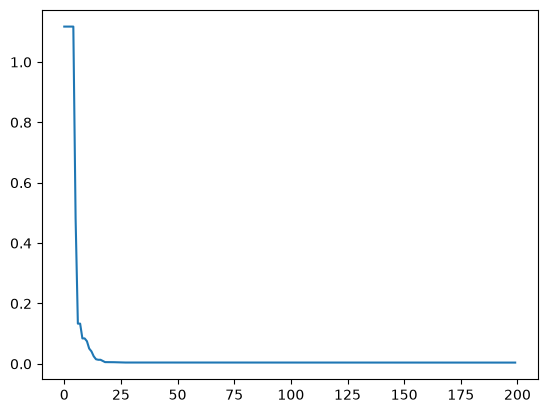

In [30]:
import matplotlib.pyplot as plt
plt.plot(error)

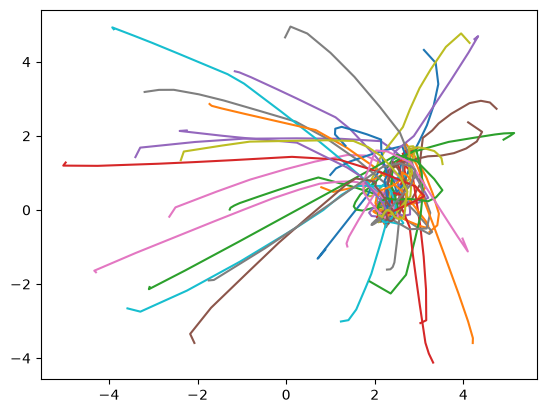

In [31]:
for a in agentes:
  xi=[Xi[0] for Xi in a.historia]
  yi=[Xi[1] for Xi in a.historia]
  if(np.random.rand()<0.05):
    plt.plot(xi,yi,'-')

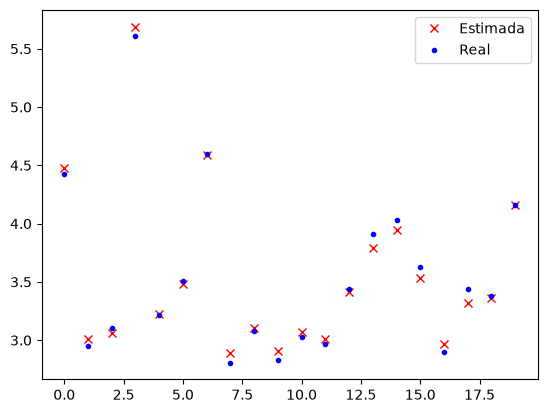

In [32]:
X=Gbest
z_est=X[0]+X[1]*x+X[2]*x**2+X[3]*y+X[4]*y**2
plt.plot(z_est,'xr', label='Estimada')
plt.plot(z,'.b', label='Real')
plt.legend()
